# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [104]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [105]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [106]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

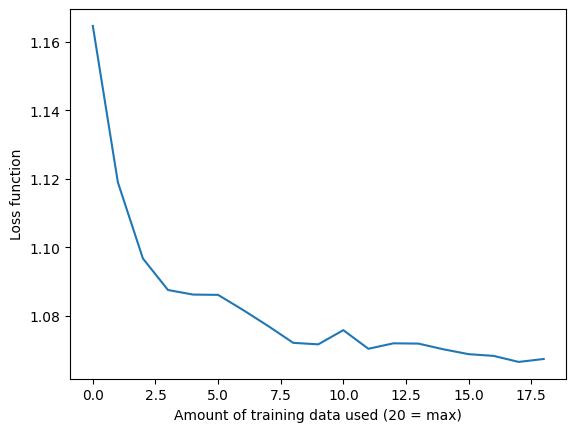

In [107]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [108]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

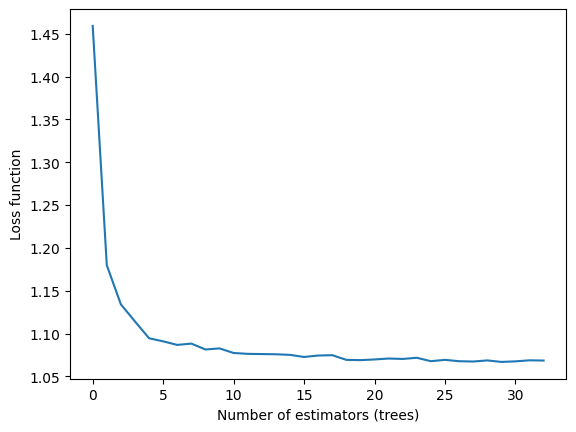

In [109]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

### Graph Analysis
I would cut the “number of estimators (trees)” plot and keep the “amount of training data used” plot.
The amount of training data on the x‑axis is more interesting, more fundamental, and more generally informative than the number of trees. The training‑data plot matters more because it tells you something fundamental about the problem. The plot of loss vs. amount of training data is a learning curve. It answers big questions:

* Is performance still improving with more data?
* Would collecting more data help?
* Is the model underfitting or overfitting?

These are problem‑level insights, not just model‑tuning insights, which are more fundamental on a high level.


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

### Load and Clean the Datasets

In [110]:
def load_and_clean_project_data():
    # Load in the census data
    census_data = pd.read_csv("data/census_data.csv", skiprows=1)
    census_data

    # Load in the Internet data
    internet_data = pd.read_csv("data/internet_data.tsv", sep="\t")
    internet_data.head()

    # Load in the ecommerce data
    ecommerce_data = pd.read_csv("data/ecommerce_data.csv")
    ecommerce_data.head()

    census_data_filtered = census_data[['Geographic Area Name','Estimate!!Households!!Median income (dollars)']]

    # Clean the Zip Code Column so it can be matched
    census_data_filtered['Geographic Area Name'] = (
        census_data_filtered['Geographic Area Name']
            .astype(str)
            .str[-5:]
    )
    census_data_filtered

    # Rename Column Names to be More Representative and use _ for analysis
    census_data_filtered = census_data_filtered.rename(
        columns={'Geographic Area Name': 'Zip_codes'}
    )
    census_data_filtered

    # Rename Column Names to be More Representative and use _ for analysis
    census_data_filtered = census_data_filtered.rename(
        columns={'Estimate!!Households!!Median income (dollars)': 'Median_household_income'}
    )
    census_data_filtered

    # There are some empty values in this column that are represented by - or **, let's take care of those
    bad_vals = ["-", "**"]
    census_data_cleaned = census_data_filtered[~census_data_filtered['Median_household_income'].isin(bad_vals)]
    census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('250,000+', '250000')
    census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('2,500-', '2500')

    # Change Median Household Income column into an int
    census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].astype(int)

    # The zip code column should be of type str and not type int
    internet_data['ZCTA19'] = internet_data['ZCTA19'].astype(str)

    # The zip code column should be of type str and not type int
    len_list = []
    for row in internet_data['ZCTA19']:
        if len(row) not in len_list:
            len_list.append(len(row))
    internet_data['ZCTA19'] = internet_data['ZCTA19'].astype(str).str.zfill(5)

    # The zip code column should be of type str and not type int
    len_list = []
    for row in internet_data['ZCTA19']:
        if len(row) not in len_list:
            len_list.append(len(row))

    # Rename Column Names to be More Representative and use _ for analysis
    internet_data_cleaned = internet_data.rename(
        columns={'ZCTA19': 'Zip_codes'}
    )

    # Rename Column Names to be More Representative and use _ for analysis
    internet_data_cleaned = internet_data_cleaned.rename(
        columns={'HOUSEHOLDS': 'Total_households'}
    )
    # Rename Column Names to be More Representative and use _ for analysis
    internet_data_cleaned = internet_data_cleaned.rename(
        columns={'N_INTERNET_SUB': 'Households_w_internet_access'}
    )

    # Only selectint the relevant columns from the internet data
    internet_data_filtered = internet_data_cleaned[['Zip_codes', 'Total_households', 'Households_w_internet_access']]

    # Add a column to Show Percentage of Households with Internet Access
    internet_data_filtered['Internet_access'] = internet_data_filtered['Households_w_internet_access'] / internet_data_filtered['Total_households']

    # Drop the null values
    internet_data_filtered = internet_data_filtered.dropna()

    # Switching the Postal Code to be a string data type
    ecommerce_data['Postal Code'] = ecommerce_data['Postal Code'].astype('string')
    # Ensure 5-character postal codes with leading zeros
    ecommerce_data["Postal Code"] = ecommerce_data["Postal Code"].astype(str).str.zfill(5)
    # Group ecommerce data by postal code
    ecommerce_data_filtered = ecommerce_data.groupby('Postal Code').size().reset_index(name="order_count")

    # Rename Column Names to be More Representative and use _ for analysis
    ecommerce_data_filtered = ecommerce_data_filtered.rename(
        columns={'Postal Code': 'Zip_codes'}
    )
    ecommerce_data_filtered

    merged_df = (
        census_data_filtered
        .merge(internet_data_filtered, on='Zip_codes', how='inner')
        .merge(ecommerce_data_filtered, on='Zip_codes', how='inner')
    )

    # Change Median Household Income column into an int
    merged_df['Median_household_income'] = merged_df['Median_household_income'].astype(int)
    return merged_df
    

In [111]:
merged_df = load_and_clean_project_data()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Zip_codes                     437 non-null    object 
 1   Median_household_income       437 non-null    int64  
 2   Total_households              437 non-null    int64  
 3   Households_w_internet_access  437 non-null    int64  
 4   Internet_access               437 non-null    float64
 5   order_count                   437 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 20.6+ KB


/tmp/ipykernel_2591/3999245414.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_filtered['Geographic Area Name'] = (
/tmp/ipykernel_2591/3999245414.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('250,000+', '250000')
/tmp/ipykernel_2591/3999245414.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [112]:
merged_df.head(5)

,Zip_codes,Median_household_income,Total_households,Households_w_internet_access,Internet_access,order_count
0,01841,45486,15149,10693,0.705855,12
1,01852,65445,14255,10844,0.760716,7
2,02038,118193,11941,11205,0.938364,2
3,02138,104641,14188,12513,0.881942,2
4,02149,70627,16021,13483,0.841583,9


In [113]:
X_cols = merged_df[["Median_household_income", "Total_households", "Households_w_internet_access", "Internet_access"]]
X_cols

,Median_household_income,Total_households,Households_w_internet_access,Internet_access
0,45486,15149,10693,0.705855
1,65445,14255,10844,0.760716
2,118193,11941,11205,0.938364
3,104641,14188,12513,0.881942
4,70627,16021,13483,0.841583
...,...,...,...,...
432,74031,14290,12469,0.872568
433,51188,20963,17051,0.813385
434,59466,18797,16371,0.870937
435,42913,12204,10541,0.863733


In [114]:
target_col = merged_df[["order_count"]]
target_col

,order_count
0,12
1,7
2,2
3,2
4,9
...,...
432,2
433,2
434,1
435,4


## Perform Random Forest Regression

### Train Test Split

In [115]:
# Useful imports and utilities
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,r2_score
from sklearn.model_selection import train_test_split

In [116]:
# Split the data into training and held out for evaluation sets

x_train, x_test, y_train ,y_test = train_test_split(
    X_cols,
    target_col,
    test_size=0.3
)

### Define the Model

In [117]:
# Import Randomized Search cv
from sklearn.model_selection import RandomizedSearchCV

In [118]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 5]
}

In [119]:
rcv = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=0,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    random_state=0
)

### Train on the Model

In [120]:
rcv.fit(x_train, y_train)

/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/Module-B-semester-2/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vec

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 5], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [121]:
print(rcv.best_estimator_)
print(rcv.best_params_)
print(rcv.best_score_)

RandomForestRegressor(max_depth=20, min_samples_leaf=5, n_estimators=50,
                      n_jobs=-1, random_state=0)
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 20}
-0.023312450913616934


### Run the Model on the Test Set

In [ ]:
# Evaluate on test data
best_model = rcv.best_estimator_
y_pred = best_model.predict(x_test)

print("Test R2:", r2_score(y_test, y_pred))

### This Model needs to be Improved, its performing worse than a random guess. This is because on the Zip Code Level there is very limited data; therefore, I will look on the state level and find more data. Seek Wee 12 for this Analysis

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

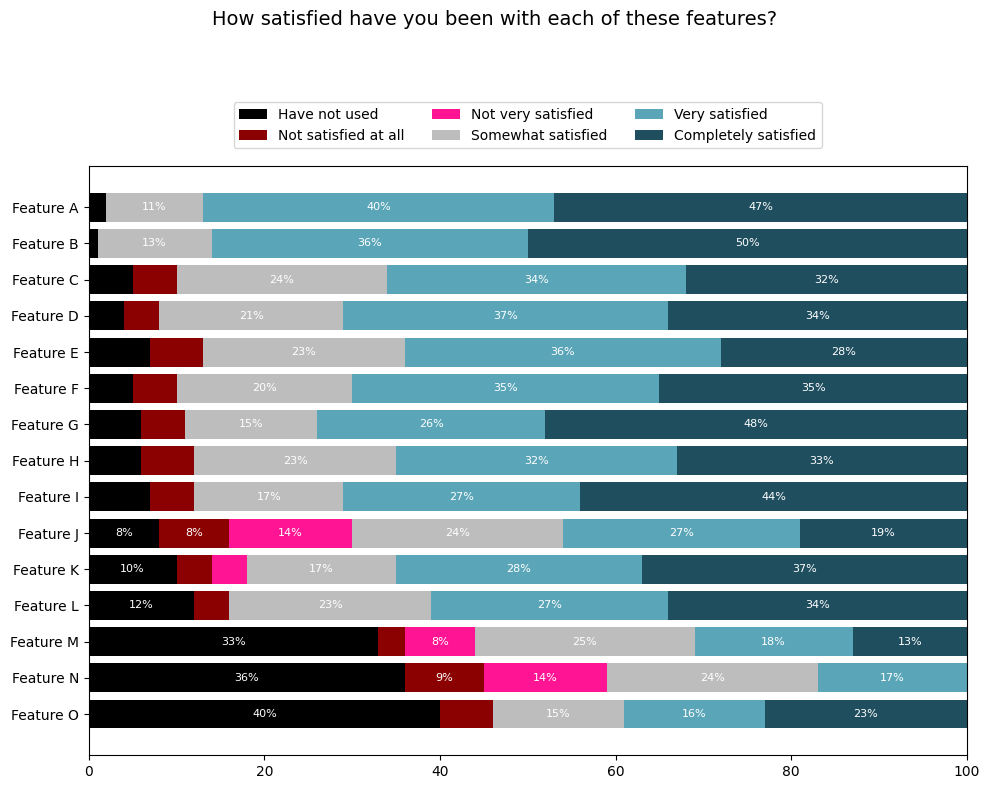

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Features
features = [f'Feature {c}' for c in list("ABCDEFGHIJKLMNO")]

# Dummy percentage data (each row sums to ~100)
have_not_used = np.array([2, 1, 5, 4, 7, 5, 6, 6, 7, 8, 10, 12, 33, 36, 40])
not_satisfied = np.array([0, 0, 5, 4, 6, 5, 5, 6, 5, 8, 4, 4, 3, 9, 6])
not_very_satisfied = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 14, 4, 0, 8, 14, 0])
somewhat_satisfied = np.array([11, 13, 24, 21, 23, 20, 15, 23, 17, 24, 17, 23, 25, 24, 15])
very_satisfied = np.array([40, 36, 34, 37, 36, 35, 26, 32, 27, 27, 28, 27, 18, 17, 16])

# Compute remaining so total = 100
completely_satisfied = 100 - (
    have_not_used +
    not_satisfied +
    not_very_satisfied +
    somewhat_satisfied +
    very_satisfied
)

# Setup
y = np.arange(len(features))
fig, ax = plt.subplots(figsize=(10, 8))

# Colors (approximate to original)
colors = {
    "have_not_used": "#000000",
    "not_satisfied": "#8b0000",
    "not_very_satisfied": "#ff1493",
    "somewhat": "#bdbdbd",
    "very": "#5aa6b8",
    "completely": "#1f4e5f"
}

left = np.zeros(len(features))

# Plot stacked bars
ax.barh(y, have_not_used, color=colors["have_not_used"], left=left, label='Have not used')
left += have_not_used

ax.barh(y, not_satisfied, color=colors["not_satisfied"], left=left, label='Not satisfied at all')
left += not_satisfied

ax.barh(y, not_very_satisfied, color=colors["not_very_satisfied"], left=left, label='Not very satisfied')
left += not_very_satisfied

ax.barh(y, somewhat_satisfied, color=colors["somewhat"], left=left, label='Somewhat satisfied')
left += somewhat_satisfied

ax.barh(y, very_satisfied, color=colors["very"], left=left, label='Very satisfied')
left += very_satisfied

ax.barh(y, completely_satisfied, color=colors["completely"], left=left, label='Completely satisfied')

# Add labels inside larger segments
def add_labels(values, starts):
    for i, (v, s) in enumerate(zip(values, starts)):
        if v >= 8:
            ax.text(s + v/2, i, f"{int(v)}%", va='center', ha='center', color='white', fontsize=8)

left = np.zeros(len(features))
add_labels(have_not_used, left)
left += have_not_used

add_labels(not_satisfied, left)
left += not_satisfied

add_labels(not_very_satisfied, left)
left += not_very_satisfied

add_labels(somewhat_satisfied, left)
left += somewhat_satisfied

add_labels(very_satisfied, left)
left += very_satisfied

add_labels(completely_satisfied, left)

# Formatting
ax.set_yticks(y)
ax.set_yticklabels(features)
ax.invert_yaxis()
ax.set_xlim(0, 100)

# Title (figure-level) and legend spacing fix
fig.suptitle(
    'How satisfied have you been with each of these features?',
    fontsize=14,
    y=0.98
)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3)

# Leave room at the top for title + legend
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()